# 00. BanglaGamba Pretraining Corpus & Normalization Audit EDA

This notebook presents a comprehensive Exploratory Data Analysis (EDA) and structural audit of the **BanglaGamba** pretraining dataset (~10.27 Billion total tokens across 52 dataset shards) and its Unicode normalization pipeline.

In [1]:
import sys
import os
import warnings

warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))

import utils.eda_helpers as eda

## 1. Structural Integrity & Dimension Audit

Before model training, every pretokenized memory-mapped `.npy` array must be audited to verify:
- **Sequence Length Uniformity**: Ensuring every row vector exactly matches the target context length ($T = 2048$).
- **Vocabulary Bound Enforcement**: Scanning every array element to confirm no out-of-bounds or corrupted token IDs exist ($0 \le \text{Token ID} < 48,000$).

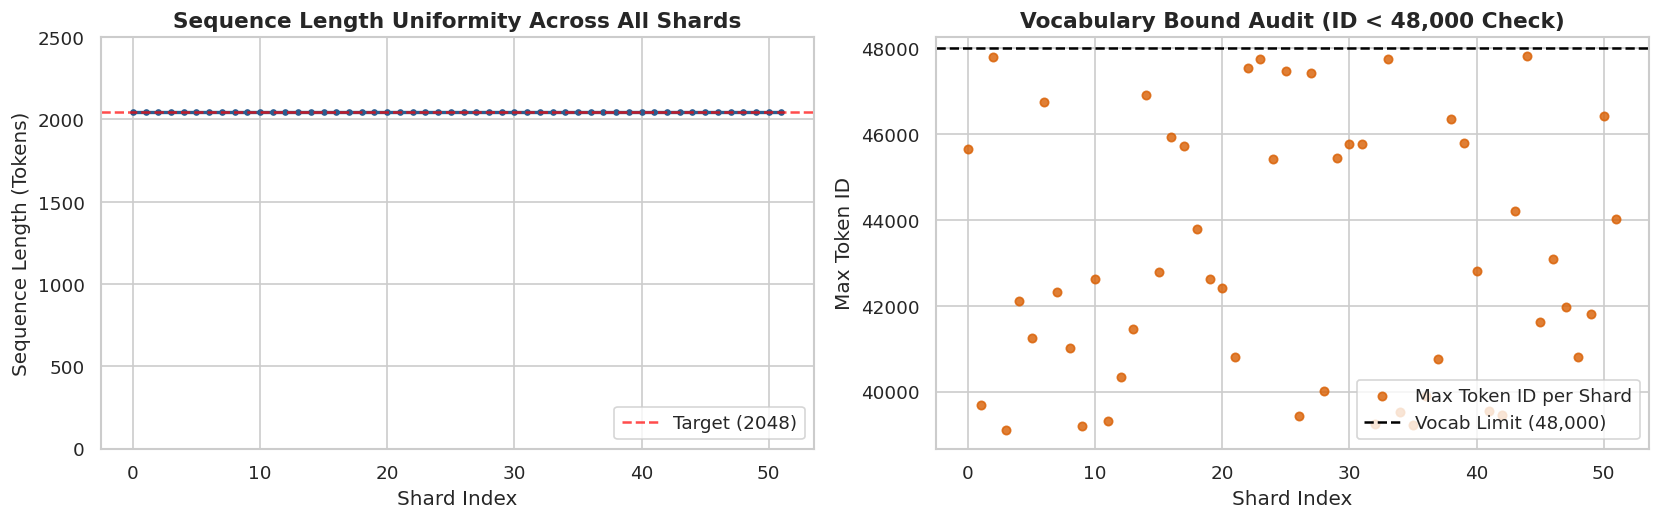

In [2]:
df_audit = eda.audit_structural_integrity(["../saved/data/train", "../saved/data/eval"])
eda.plot_structural_integrity(df_audit)

## 2. Pretraining & Evaluation Corpus Composition

The **BanglaGamba** corpus is a balanced multi-domain pretraining dataset comprising:
- **Bangla Monolingual (`bn`)**: Large-scale cleaned web text and Wikipedia.
- **English Monolingual (`en`)**: High-quality English pretraining shards.
- **Sangraha Bangla (`sn`)**: AI4Bharat Sangraha Bengali corpus (West Bengal & regional dialect text).
- **Parallel Translation Pairs (`nmt`)**: Bilingual sentence pairs for cross-lingual alignment.

Below we examine the total token volumes and percentage domain distributions across both **Train** (~9.62B tokens) and **Eval** (~644M tokens) splits.

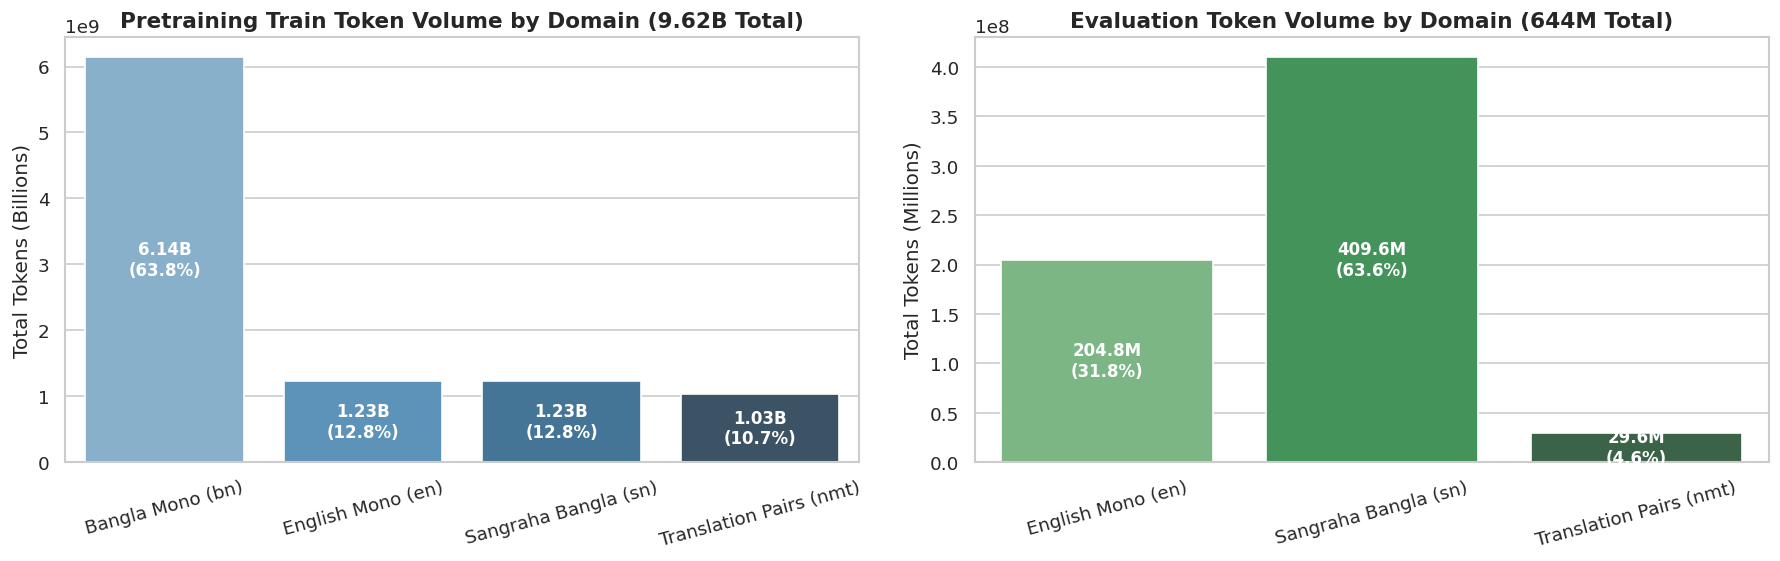

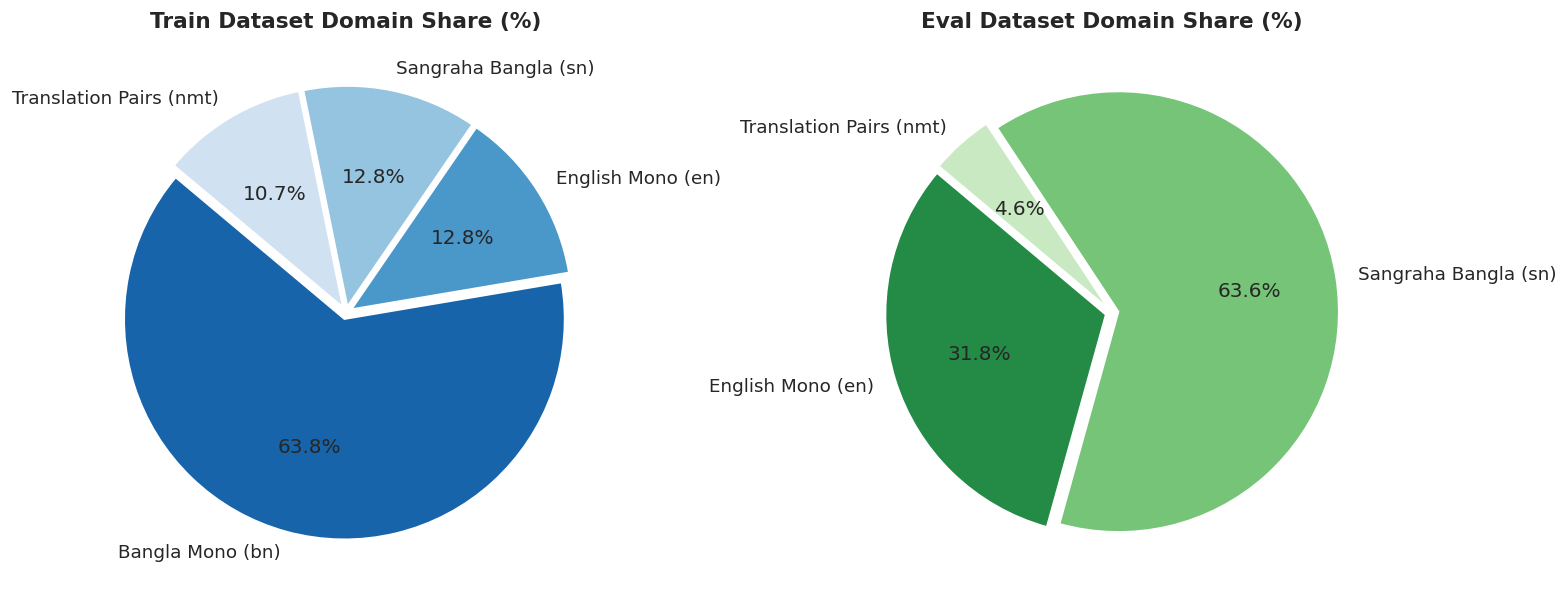

In [3]:
train_yaml, eval_yaml = eda.load_token_count_reports("../saved/reports")
df_train = eda.parse_shard_metadata(train_yaml, "Train")
df_eval = eda.parse_shard_metadata(eval_yaml, "Eval")

eda.plot_corpus_distribution(df_train, df_eval)

## 3. Sequence Packing Efficiency & Document Density

Pretraining sequences are packed with multiple documents separated by End-of-Sequence (`</s>`, ID 3) tokens.
- **Document Density**: Measures the number of distinct documents concatenated within a single 2048-token context window.
- **Padding Ratio**: Audits the percentage of unused `<pad>` tokens across shards to evaluate bin-packing waste.
- **Segment Lengths**: Analyzes the distribution of individual document token lengths.

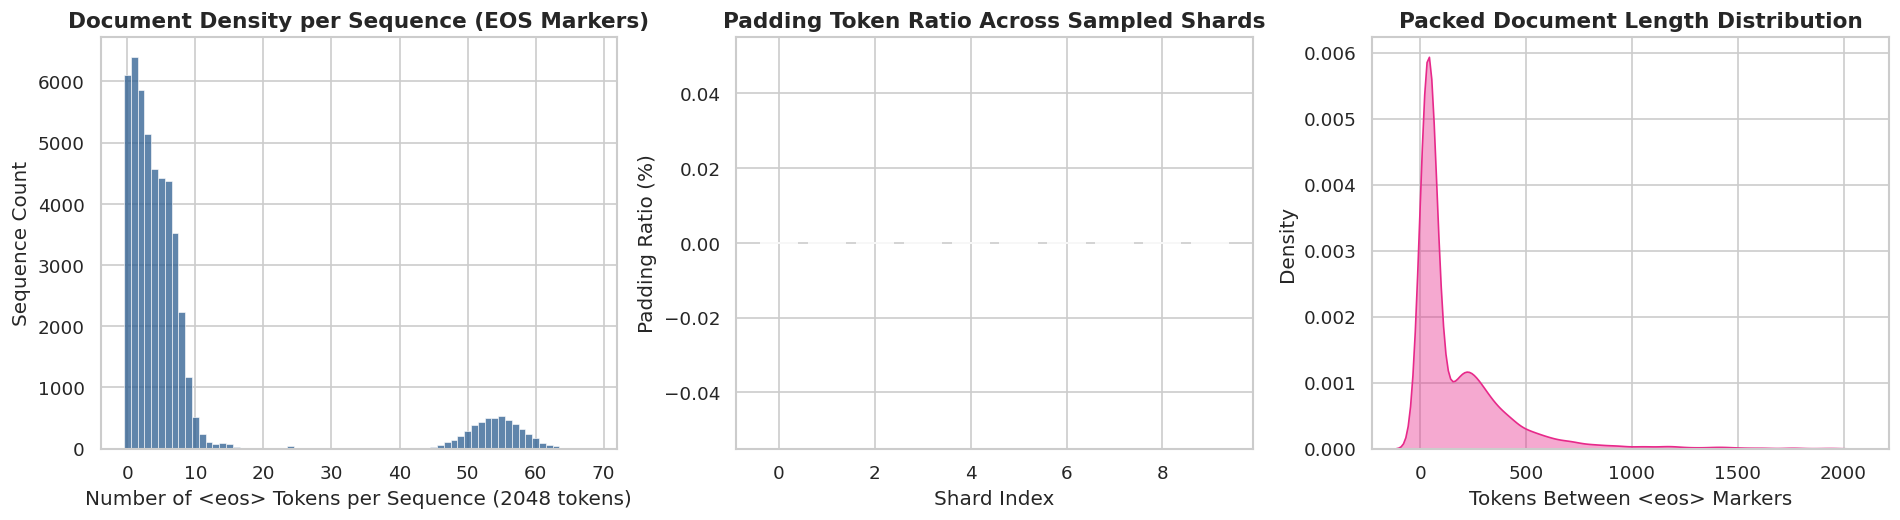

In [4]:
shard_sample = [r["path"] for r in df_train.to_dict("records")[:10]]
doc_densities, padding_ratios, segment_lengths = eda.audit_packing_and_composition(shard_sample)

eda.plot_packing_efficiency(doc_densities, padding_ratios, segment_lengths)

## 4. Token Frequency Metrics & Zipf's Law Audit

To verify vocabulary utilization and detect keyword-stuffing anomalies or runaway token loops:
- **Zipf's Law Log-Log Audit**: Plots token frequency vs. frequency rank on a log-log scale.
- **Special Token Breakdown**: Audits the occurrences of `<pad>`, `<unk>`, `<s>`, and `</s>` tokens across the corpus.

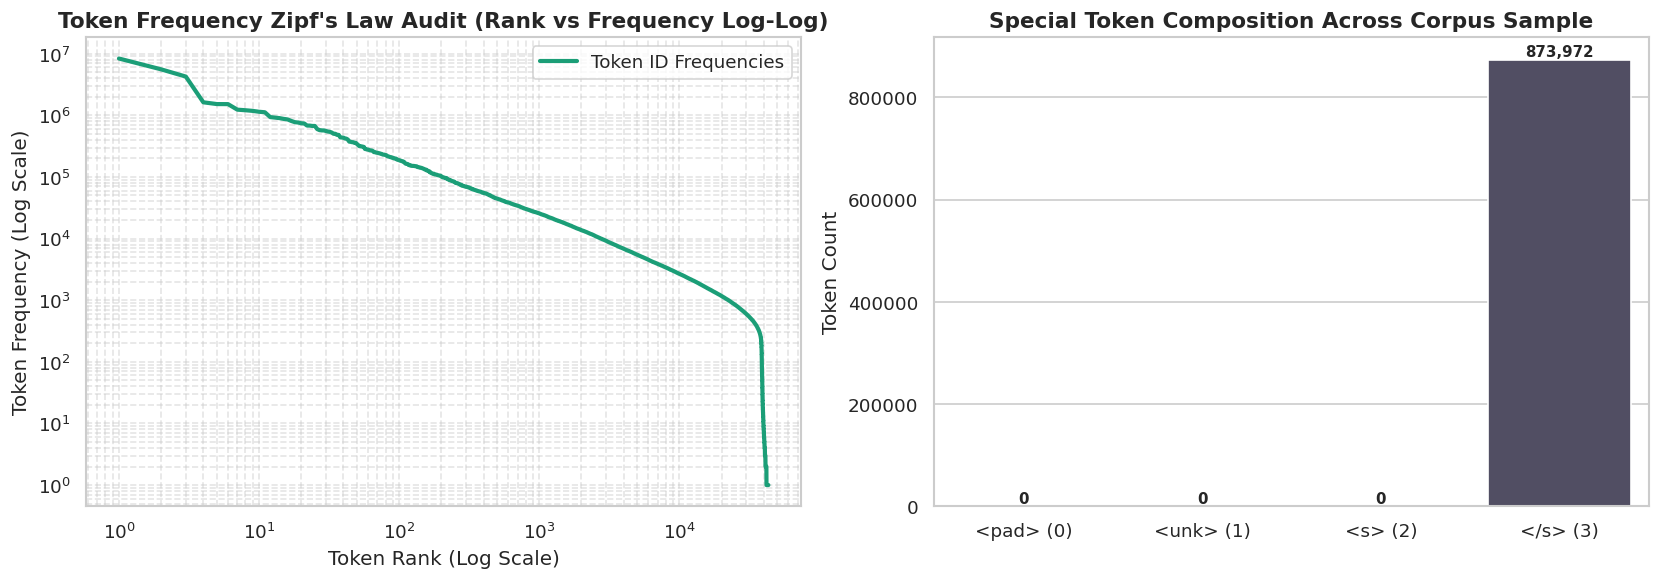

In [5]:
entropies, cov_pct, zipf_ranks, sorted_counts, global_bincount, top_50s = eda.audit_token_frequency_and_entropy(shard_sample)

eda.plot_token_frequency_and_zipf(zipf_ranks, sorted_counts, global_bincount)

## 5. Shard Uniformity & Shuffling Health

To prevent loss spikes caused by sudden domain clustering:
- **Per-Shard Shannon Entropy**: Tracks information entropy $H = -\sum p(x) \log_2 p(x)$ per shard to catch low-entropy (repetitive/corrupted) files.
- **Rolling Domain Balance**: Tracks the proportion of Bangla, English, Sangraha, and NMT tokens across pretraining shards 01 to 48.

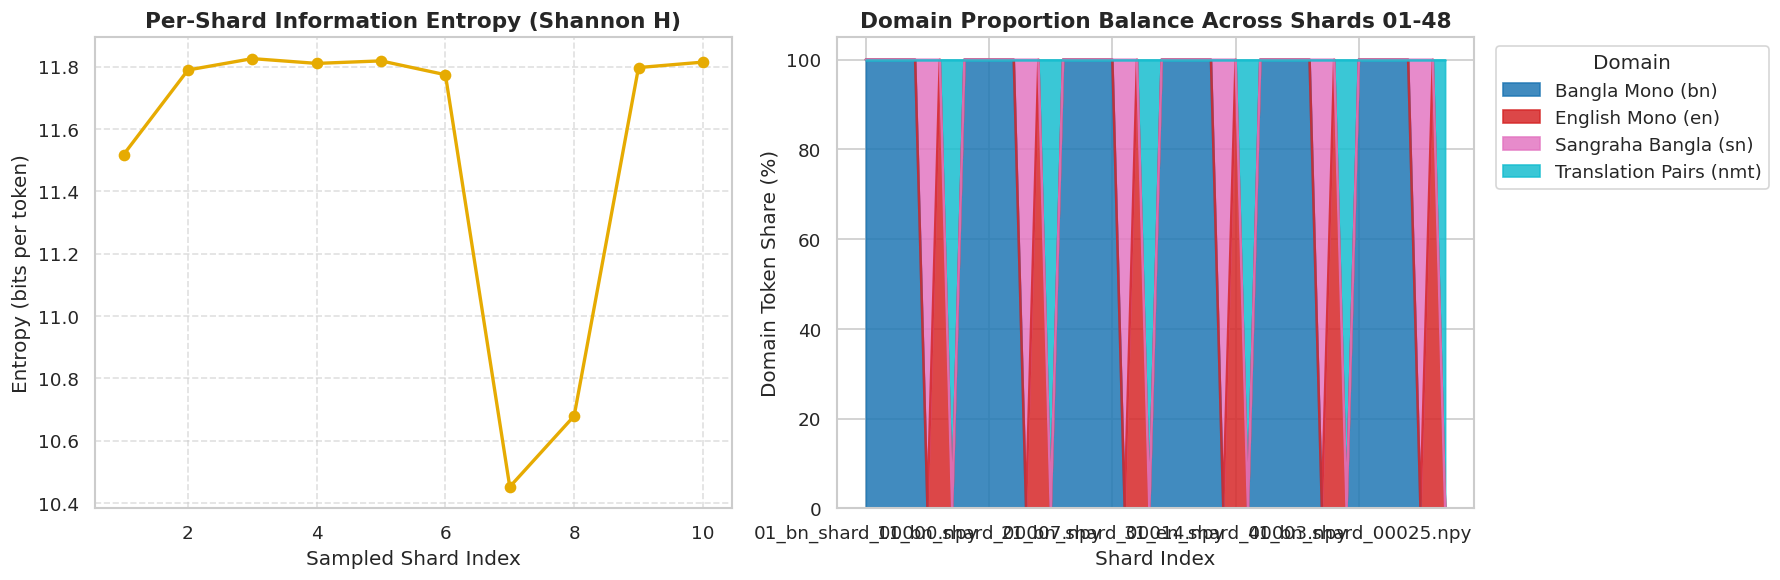

In [6]:
eda.plot_shuffling_and_uniformity(entropies, df_train)

## 6. Unicode Normalization Failure Audit Across Corpora

Text pre-processing uses `bnunicodenormalizer` with a `--none-policy drop_and_collect` rule to filter invalid or un-normalizable Bengali unicode sequences.

Below is a comparative breakdown across the 4 major source datasets:
1. `bangla_deduped`: **334,142** failure instances (235 unique tokens).
2. `sangraha_deduped`: **415,701** failure instances (205 unique tokens).
3. `nmt_deduped`: **28,106** failure instances (117 unique tokens).
4. `opus_opensubtitles`: **132,630** failure instances (7 unique tokens, dominated by standalone Virama halants `্` U+09CD).

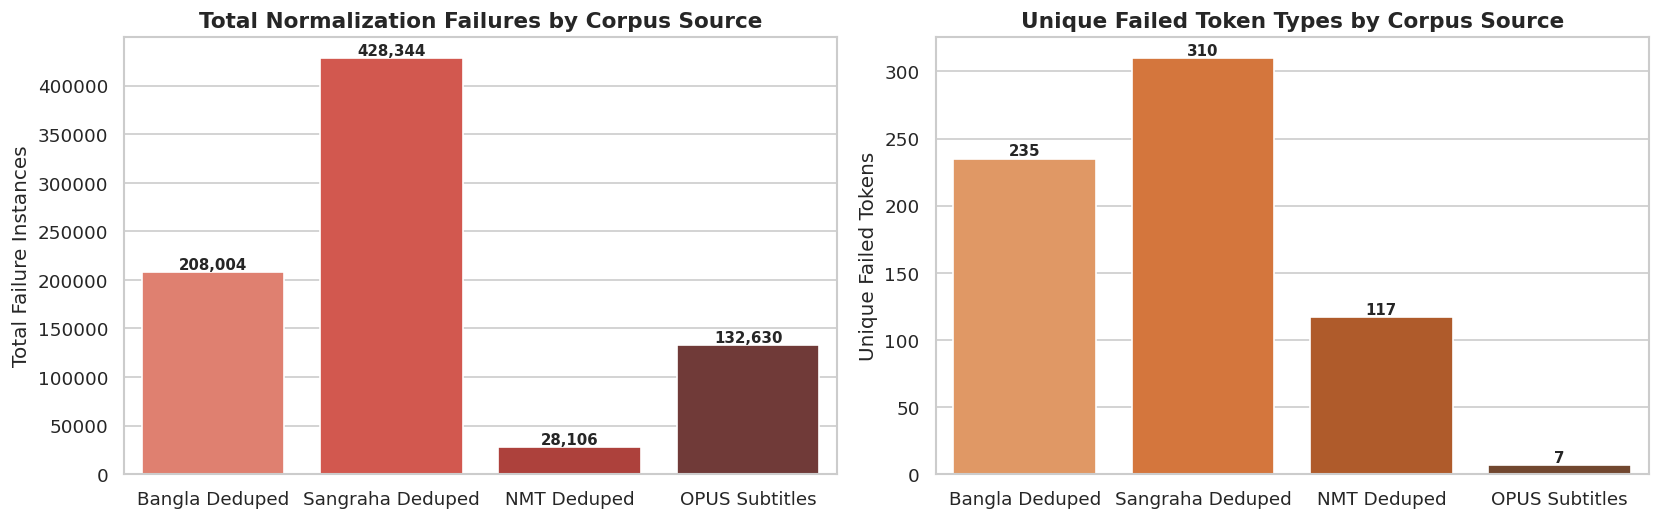

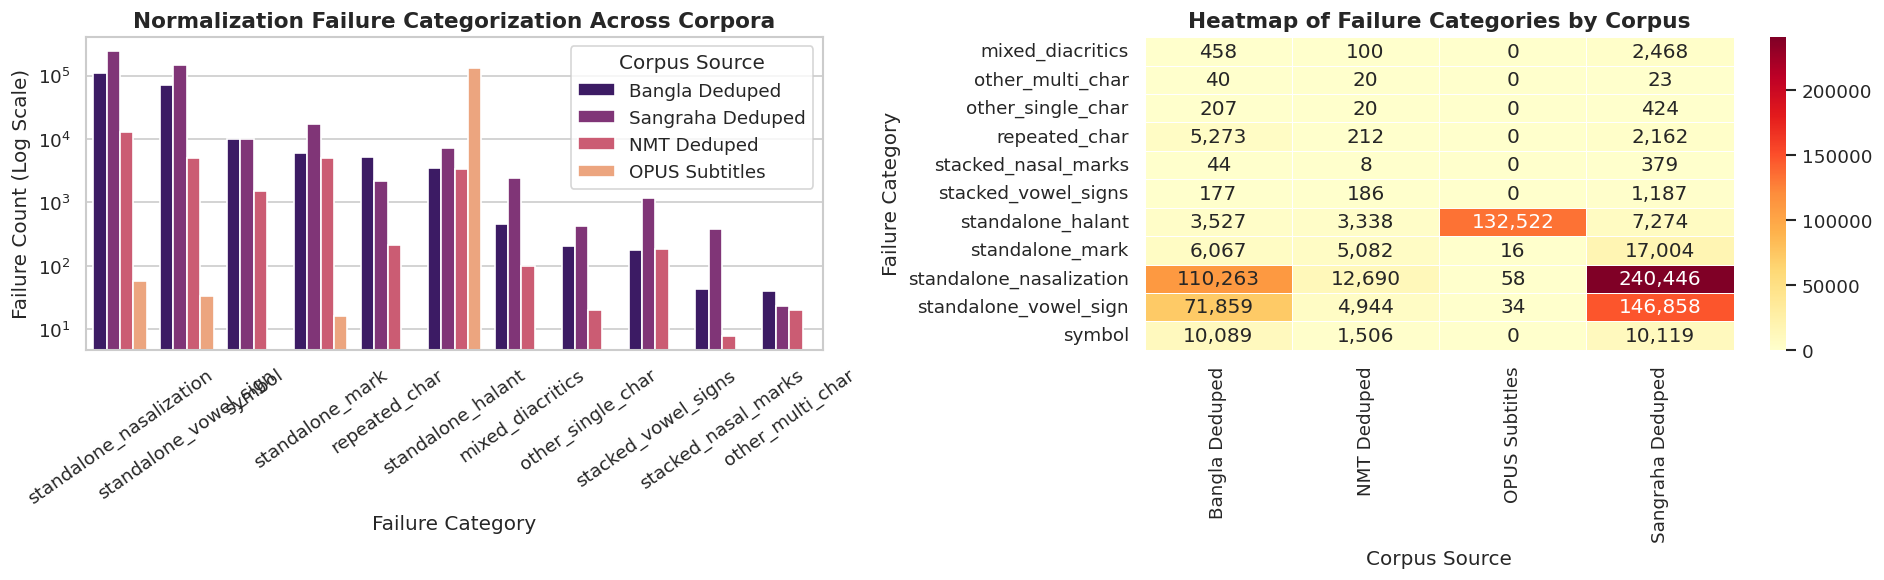

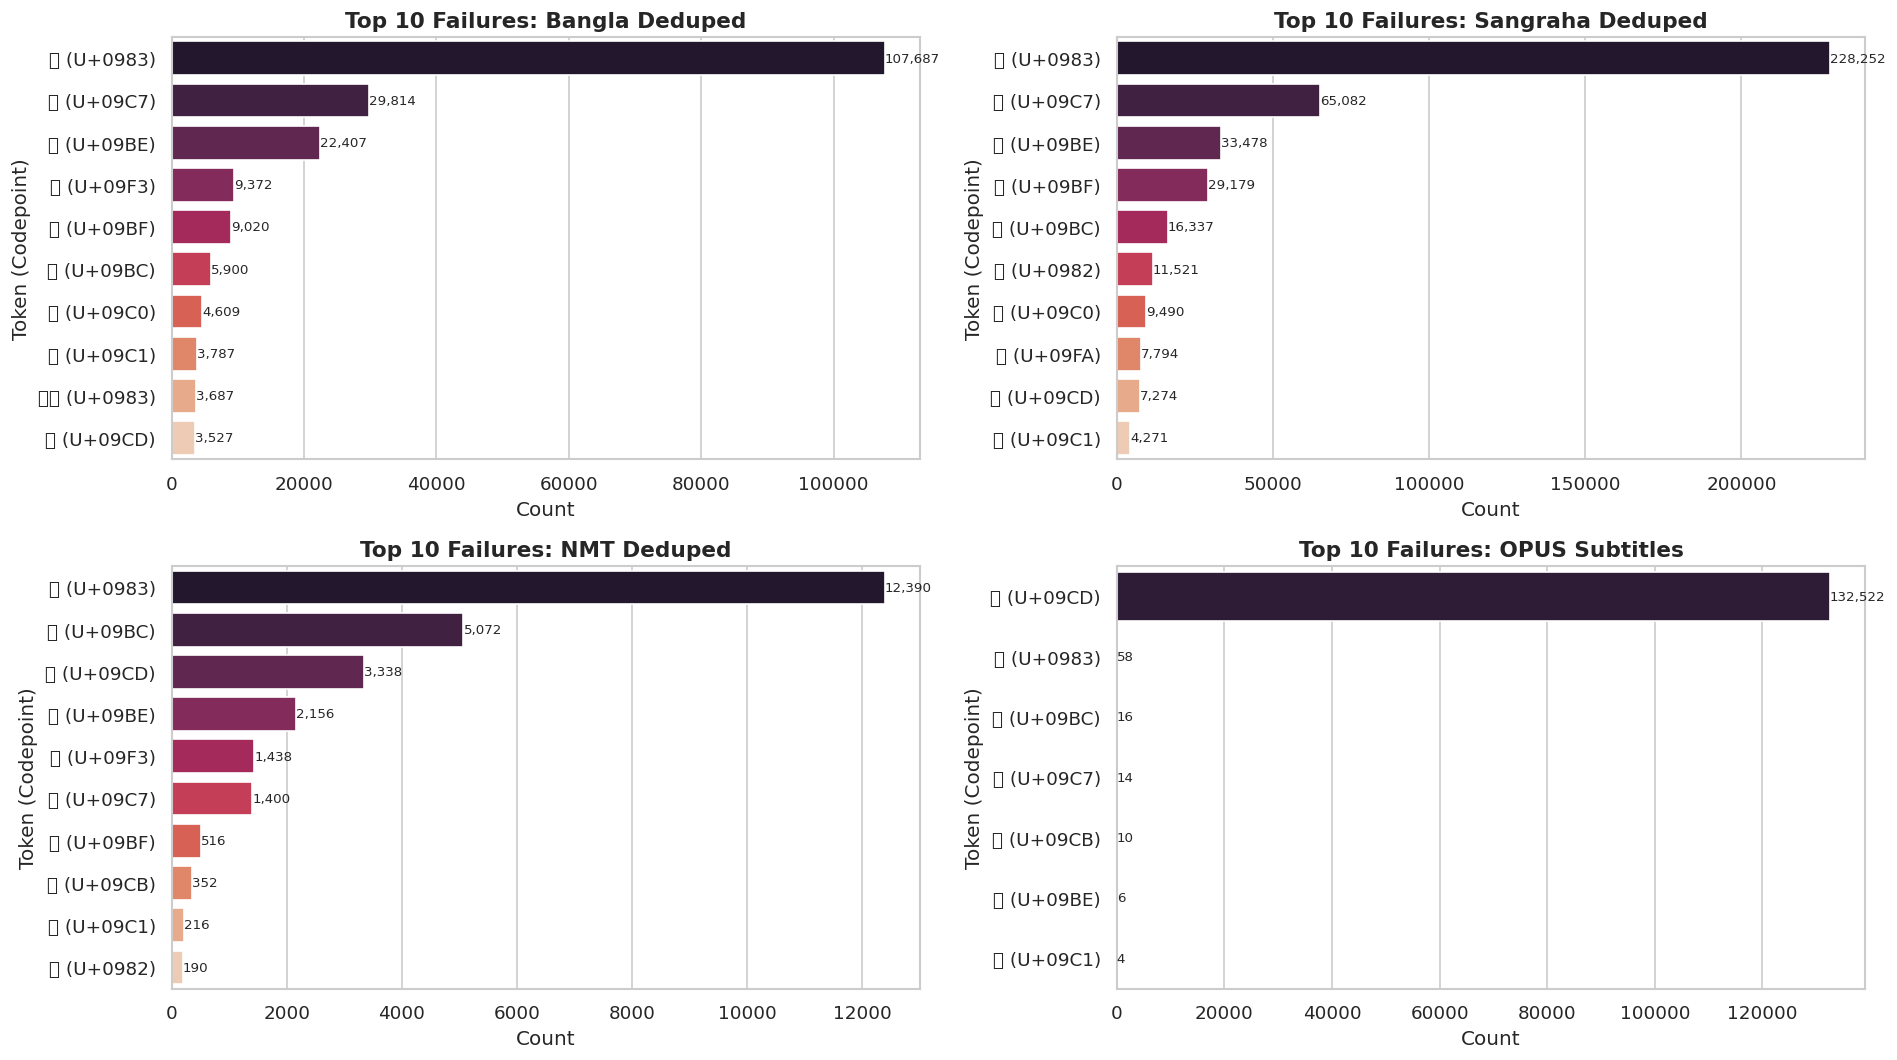

In [7]:
norm_reports = eda.load_norm_failure_reports("../saved/reports")

eda.plot_norm_failure_analysis(norm_reports)